# V42: SMA Crossover Target Strategy (LQ45)

Notebook ini bertujuan untuk memperbaiki kinerja strategi pada pasar LQ45 dengan mengubah target prediksi AI.

### Strategi Perbaikan:
1. **SMA Target Logic**: AI dilatih untuk memprediksi arah tren Moving Average (SMA5 > SMA20) di masa depan, bukan return harian. Ini mengurangi 'whiplash' (sinyal yang sering berubah-ubah).
2. **Fee Sensitivity**: Memasukkan biaya transaksi 0.25% (realistis di Indonesia).
3. **Graph Filtering**: Tetap menggunakan Maximum Independent Set (MIS) untuk diversifikasi aset berkorelasi rendah.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. Feature & SMA Trend Target Engineering ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# TREND TARGET DEFINITION
# Kita memprediksi apakah SMA5 akan lebih besar dari SMA20 dalam 5 hari ke depan (Medium-Term Bullish Trend)
sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target_signal = (sma5 > sma20).astype(int).shift(-5) 

features = features.dropna()
target = target_signal.reindex(features.index).fillna(0)

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print("Training AI with SMA Crossover Target...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Find Optimal Threshold based on F0.5 Score
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in thresholds]
opt_t = thresholds[np.argmax(scores)]
print(f"Optimized Trend Threshold: {opt_t:.2f}")

test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

Training AI with SMA Crossover Target...
Optimized Trend Threshold: 0.54


In [3]:
# --- 3. Core Logic Functions ---
def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_with_hysteresis(test_dates, returns, ai_probs, threshold=0.5, fee=0.0025, lookback=30):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    prev_weights = {}
    current_risk_status = False # Start Risk-Off
    
    # Buffer untuk mencegah pergantian posisi terlalu sering
    buffer = 0.05 
    
    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        
        # Hysteresis Logic
        if not current_risk_status and prob > (threshold + buffer):
            current_risk_status = True # Switch to Risk-On
        elif current_risk_status and prob < (threshold - buffer):
            current_risk_status = False # Switch to Risk-Off
            
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if not current_risk_status:
            weights = {'CASH': 1.0}
        else:
            selected = get_mis_assets(window_rets)
            weights = optimize_markowitz(window_rets[selected])
        
        # Turnover Tax & Fee calculation
        all_adj_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_adj_assets)
        val -= val * turnover * fee
        
        # PnL Calculation
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

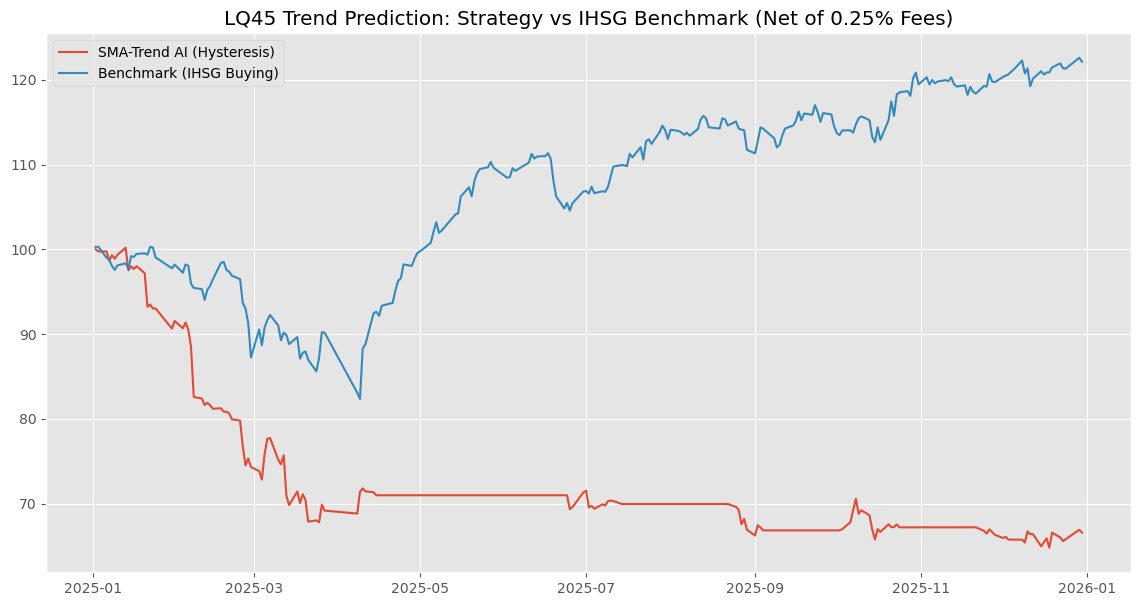

In [4]:
# --- 4. Backtest Execution ---
test_dates = test_probs.index
stock_fee = 0.0025 # 0.25%

results = {}
results['SMA-Trend AI (Hysteresis)'] = run_simulation_with_hysteresis(test_dates, returns, test_probs, threshold=opt_t, fee=stock_fee)
results['Benchmark (IHSG Buying)'] = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

plt.figure(figsize=(14, 7))
for label, df in results.items():
    plt.plot(df.index, df['Portfolio_Value'], label=label)

plt.title(f"LQ45 Trend Prediction: Strategy vs IHSG Benchmark (Net of {stock_fee*100}% Fees)")
plt.legend()
plt.show()